In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import pm4py

from scipy.stats import chi2_contingency, fisher_exact

In [29]:
# Load dataset
filepath = "generated/preprocessed_dataset.csv"
df = pd.read_csv(filepath, parse_dates=["time:timestamp"])

df["case:concept:name"] = df["case:concept:name"].astype(str)
df["time:timestamp"]= pd.to_datetime(df["time:timestamp"])

df["event_lead_time_min"] = pd.to_numeric(df["event_lead_time_min"])
df["cumulative_lead_time_min"] = pd.to_numeric(df["cumulative_lead_time_min"])

df.head()

,responsible_physician,disease,start_date,time:timestamp,concept:name,item,prescription_date,process_time,quantity,discharge_status,outlier_label,event_lead_time_min,cumulative_lead_time_min,@@index,@@case_index,case:concept:name
0,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:22:00+00:00,2020-07-21 10:22:00+00:00,Atendimento,Atendimento,NaN,0.0,0.0,Sem retorno,outlier,0.0,0.0,0,0,5446538
1,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 10:45:00+00:00,2020-07-21 10:49:00+00:00,Triagem,Triagem,NaN,0.0,0.0,Sem retorno,outlier,27.0,27.0,1,0,5446538
2,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:01:00+00:00,2020-07-21 11:01:00+00:00,Exames Laboratoriais,Coronavírus COVID-19 - Diagnóstico Molecular (...,2020-07-21 10:51:00+00:00,9.0,1.0,Sem retorno,outlier,12.0,39.0,2,0,5446538
3,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 11:32:00+00:00,2020-07-21 11:32:00+00:00,Consulta,Consulta,NaN,0.0,0.0,Sem retorno,outlier,31.0,70.0,3,0,5446538
4,Médico 72,J11.1 Influenza c/out manif resp dev virus n i...,2020-07-21 19:27:00+00:00,2020-07-21 19:27:00+00:00,Alta,Alta para completar tratamento,NaN,0.0,0.0,Sem retorno,outlier,475.0,545.0,4,0,5446538


In [30]:
def compute_case_kpis(segment_df: pd.DataFrame, label="Segment"):
    """
    Compute per-case KPIs: total case duration, case size and rework count.
    Rework is computed by counting repeated activities per case (counts > 1).
    Missing rework values are filled with 0.

    Parameters
    ----------
    segment_df : pd.DataFrame
        Event log dataframe 
    label : str, optional
        Segment label title

    Returns
    -------
    pd.DataFrame
        DataFrame indexed by `case:concept:name` with columns:
        - duration_min: max cumulative_lead_time_min per case
        - case_size: number of events per case
        - rework_count: sum of repeated activity counts per case (0 if none)
    """
    
    # Case Duration (total case duration = max cumulative_lead_time_min per case)
    duration = (
        segment_df.groupby("case:concept:name")["cumulative_lead_time_min"]
        .max()
        .rename("duration_min")
    )

    # Case Size (number of events per case)
    size = (
        segment_df.groupby("case:concept:name")["concept:name"]
        .count()
        .rename("case_size")
    )
    
    kpis = pd.concat([duration, size], axis=1).fillna(0)
    return kpis

In [31]:
def compute_case_kpis_tests(segment_a: pd.DataFrame, segment_b: pd.DataFrame, kpis_to_test):
    """
    Compute statistical tests to compare KPIs between two segments.
     - For each KPI, test normality with Shapiro-Wilk.
     - If both are normal, use T-test (Welch's if variances differ).
     - If at least one is non-normal, use Mann-Whitney U test.
     - Print results and conclusions for each KPI.

    Parameters
    ----------
    segment_a : pd.DataFrame
        First segment dataframe
    segment_b : pd.DataFrame
        Second segment dataframe
    kpis_to_test : list[str]
        List of KPI column names to compare
    """
    # Threshold for minimum sample size to perform normality test (Shapiro-Wilk is not reliable for large samples)
    N_THRESHOLD = 1000

    for kpi in kpis_to_test:
        data_a = segment_a[kpi].dropna()
        data_b = segment_b[kpi].dropna()
        
        n_a = len(data_a)
        n_b = len(data_b)
        
        print(f"--- KPI: {kpi} (Sample sizes: a={len(data_a)}, b={len(data_b)}) ---")
        
        # Check if sample sizes are too large for Shapiro-Wilk normality test
        if n_a > N_THRESHOLD or n_b > N_THRESHOLD:
            print(f"To large samples (>{N_THRESHOLD}), we skip Shapiro-Wilk and rely on Central Limit Theorem for normality.")
            res_test = stats.ttest_ind(data_a, data_b, equal_var=False) 
            test_name = "T-test (Welch)"
        else:
            # Normality test (Shapiro-Wilk)
            _, p_shapiro_a = stats.shapiro(data_a)
            _, p_shapiro_b = stats.shapiro(data_b)
            
            is_normal_a = p_shapiro_a > 0.05
            is_normal_b = p_shapiro_b > 0.05
            
            print(f"Normality of segment a (Shapiro p-value): {p_shapiro_a:.4f} -> {'Normal' if is_normal_a else 'Non-normal'}")
            print(f"Normality of segment b (Shapiro p-value): {p_shapiro_b:.4f} -> {'Normal' if is_normal_b else 'Non-normal'}")
            
            # Select test based on normality
            if is_normal_a and is_normal_b:
                print("Each sample are normal, we use T-test.")
                # equal_var=False applies Welch's t-test, which is more robust when variances are unequal
                res_test = stats.ttest_ind(data_a, data_b, equal_var=False) 
                test_name = "T-test"
            else:
                print("At least one sample is not normal. Performing Mann-Whitney U test.")
                res_test = stats.mannwhitneyu(data_a, data_b, alternative='two-sided')
                test_name = "Mann-Whitney U"

        p_val = float(res_test.pvalue)

        # Final conclusion
        print(f"Risultato {test_name} p-value: {p_val:.4f}")
        if p_val < 0.05:
            print(f"✅ There is a statistically significant difference between the two segments for '{kpi}'.\n")
        else:
            print(f"❌ There is NOT a statistically significant difference between the two segments for '{kpi}'.\n")

### Discharge status segmentation analysis

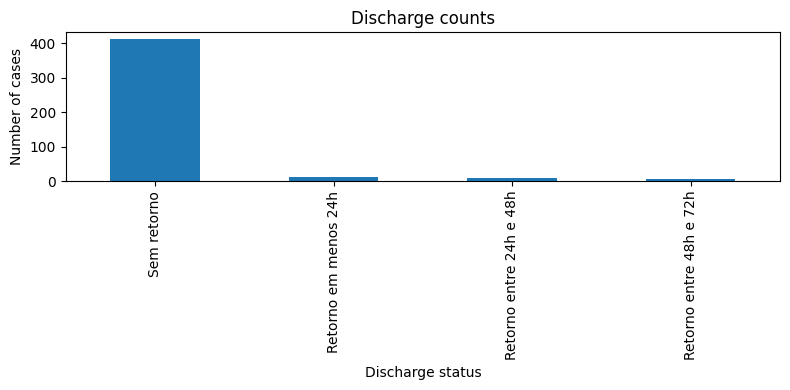

discharge_status
Sem retorno                411
Retorno em menos 24h        11
Retorno entre 24h e 48h      8
Retorno entre 48h e 72h      6
Name: count, dtype: int64

In [32]:
# Discharge frequency
discharge_counts = df.groupby("case:concept:name")["discharge_status"].first().value_counts()

ax = discharge_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Discharge counts")
ax.set_xlabel("Discharge status")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

discharge_counts

In [33]:
# Segment by discharge status
discharged = df[df["discharge_status"] == "Sem retorno"] # cases discharged 
readmitted = df[df["discharge_status"] != "Sem retorno"] # cases with readmission

In [34]:
# Compute KPIs for each segment
kpi_discharged = compute_case_kpis(discharged, "Sem Retorno")
print(f"=== Discharged ===")
print(kpi_discharged.describe())

kpi_readmitted = compute_case_kpis(readmitted, "Com Retorno")
print(f"\n=== Readmitted ===")
print(kpi_readmitted.describe())

=== Discharged ===
       duration_min   case_size
count    411.000000  411.000000
mean     129.394161    6.564477
std      199.302847    5.766819
min        8.000000    3.000000
25%       45.000000    4.000000
50%       80.000000    4.000000
75%      150.500000    5.000000
max     3221.000000   60.000000

=== Readmitted ===
       duration_min  case_size
count     25.000000  25.000000
mean     185.600000   9.400000
std      154.179279   6.103278
min       35.000000   4.000000
25%       93.000000   5.000000
50%      155.000000   7.000000
75%      245.000000  14.000000
max      773.000000  28.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_22244\1998583726.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Discharge status', y='duration_min', ax=ax3, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_22244\1998583726.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='Discharge status', y='case_size', ax=ax4, palette='Set2', cut=0)


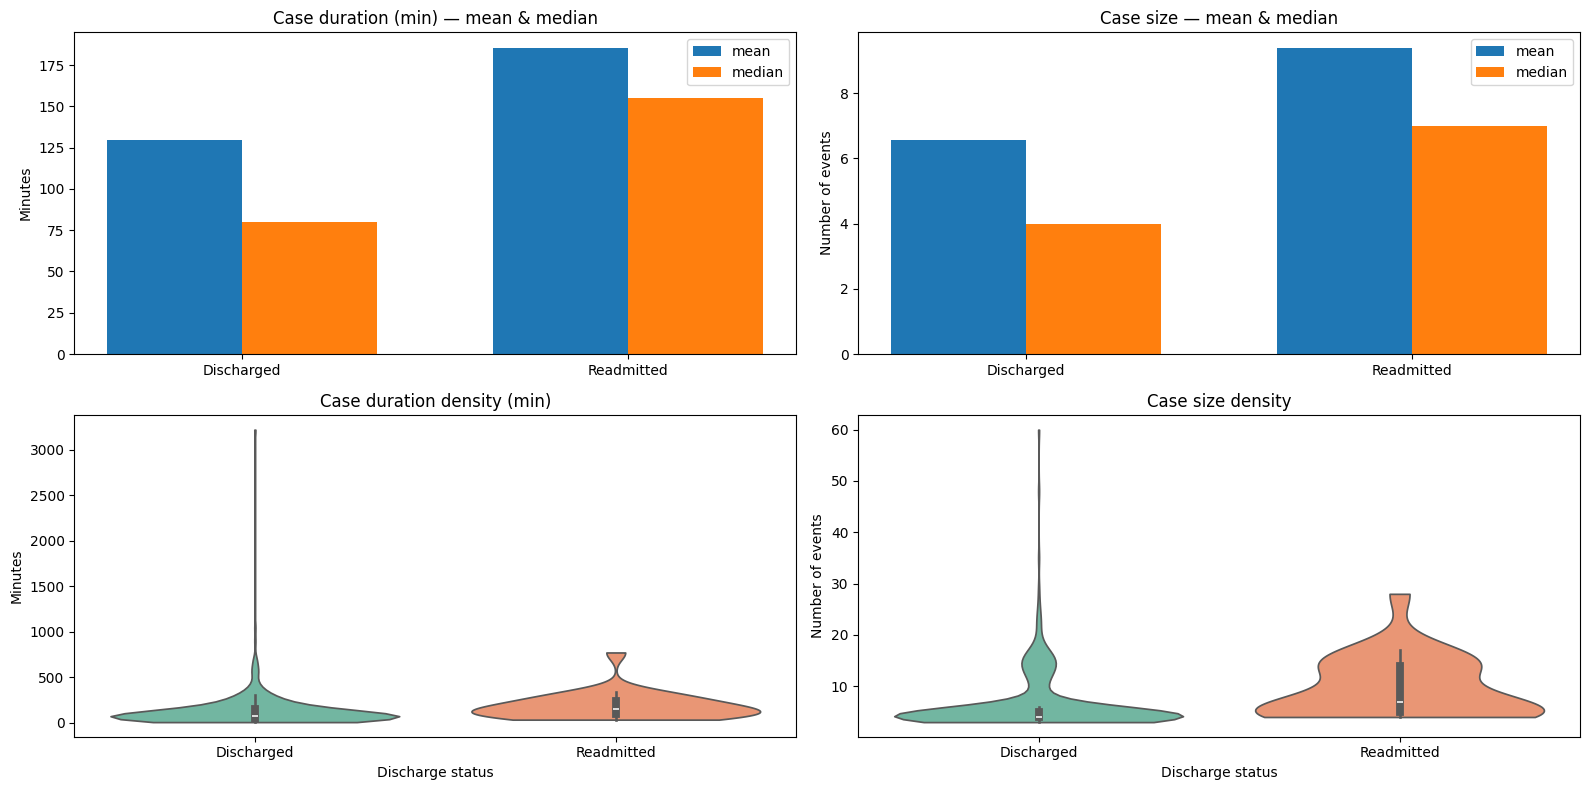

In [35]:
# Plot mean and median for duration and case size per segment
dur_mean = [kpi_discharged["duration_min"].mean(), kpi_readmitted["duration_min"].mean()]
dur_med = [kpi_discharged["duration_min"].median(), kpi_readmitted["duration_min"].median()]

size_mean = [kpi_discharged["case_size"].mean(), kpi_readmitted["case_size"].mean()]
size_med = [kpi_discharged["case_size"].median(), kpi_readmitted["case_size"].median()]

kpi_discharged_plot = kpi_discharged.copy()
kpi_discharged_plot['Discharge status'] = 'Discharged'

kpi_readmitted_plot = kpi_readmitted.copy()
kpi_readmitted_plot['Discharge status'] = 'Readmitted'

combined_kpis = pd.concat([kpi_discharged_plot, kpi_readmitted_plot])

labels = ["Discharged", "Readmitted"]
x = [0, 1]
width = 0.35

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))

# Duration plot
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()

# Case size plot
ax2.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax2.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("Case size — mean & median")
ax2.set_ylabel("Number of events")
ax2.legend()

# Duration plot
sns.violinplot(data=combined_kpis, x='Discharge status', y='duration_min', ax=ax3, palette='Set2', cut=0)
ax3.set_title("Case duration density (min)")
ax3.set_ylabel("Minutes")

# Case size plot
sns.violinplot(data=combined_kpis, x='Discharge status', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")
ax4.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [36]:
# Test KPIs between segments by Retorno (discharge)
print("\n=== Statistical Analysis ===")
kpis_to_test = ["duration_min", "case_size"]
compute_case_kpis_tests(kpi_discharged, kpi_readmitted, kpis_to_test)


=== Statistical Analysis ===
--- KPI: duration_min (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0001 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0021
✅ There is a statistically significant difference between the two segments for 'duration_min'.

--- KPI: case_size (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0004 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between the two segments for 'case_size'.



Conclusion: There are a significant difference for case duration and case size between discharge and no discharge segment.

### Outlier segmentation analysis

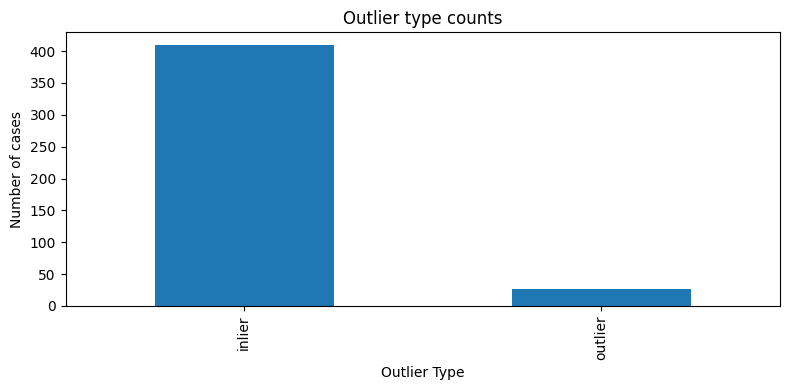

outlier_label
inlier     409
outlier     27
Name: count, dtype: int64

In [37]:
# Outlier frequency
outlier_counts = df.groupby("case:concept:name")["outlier_label"].first().value_counts()

ax = outlier_counts.plot(kind="bar", figsize=(8, 4))
ax.set_title("Outlier type counts")
ax.set_xlabel("Outlier Type")
ax.set_ylabel("Number of cases")

plt.tight_layout()
plt.show()

outlier_counts

In [38]:
# Segment by outlier type
outliers = df[df["outlier_label"] == "outlier"]
inlier = df[df["outlier_label"] != "outlier"]

In [39]:
# Compute KPIs for each segment
kpi_outlier = compute_case_kpis(outliers, "outlier")
print(f"\n=== Outliers ===")
print(kpi_outlier.describe())

kpi_inlier = compute_case_kpis(inlier, "inlier")
print(f"\n=== Inliers ===")
print(kpi_inlier.describe())


=== Outliers ===
       duration_min  case_size
count     27.000000  27.000000
mean     619.037037  14.814815
std      552.073747  13.964342
min      334.000000   4.000000
25%      364.000000   5.000000
50%      465.000000  12.000000
75%      646.500000  16.500000
max     3221.000000  60.000000

=== Inliers ===
       duration_min   case_size
count    409.000000  409.000000
mean     100.506112    6.193154
std       73.370538    4.362760
min        8.000000    3.000000
25%       44.000000    4.000000
50%       78.000000    4.000000
75%      136.000000    5.000000
max      324.000000   29.000000


C:\Users\milan\AppData\Local\Temp\ipykernel_22244\1683579592.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax3, palette='Set2', cut=0)
C:\Users\milan\AppData\Local\Temp\ipykernel_22244\1683579592.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)


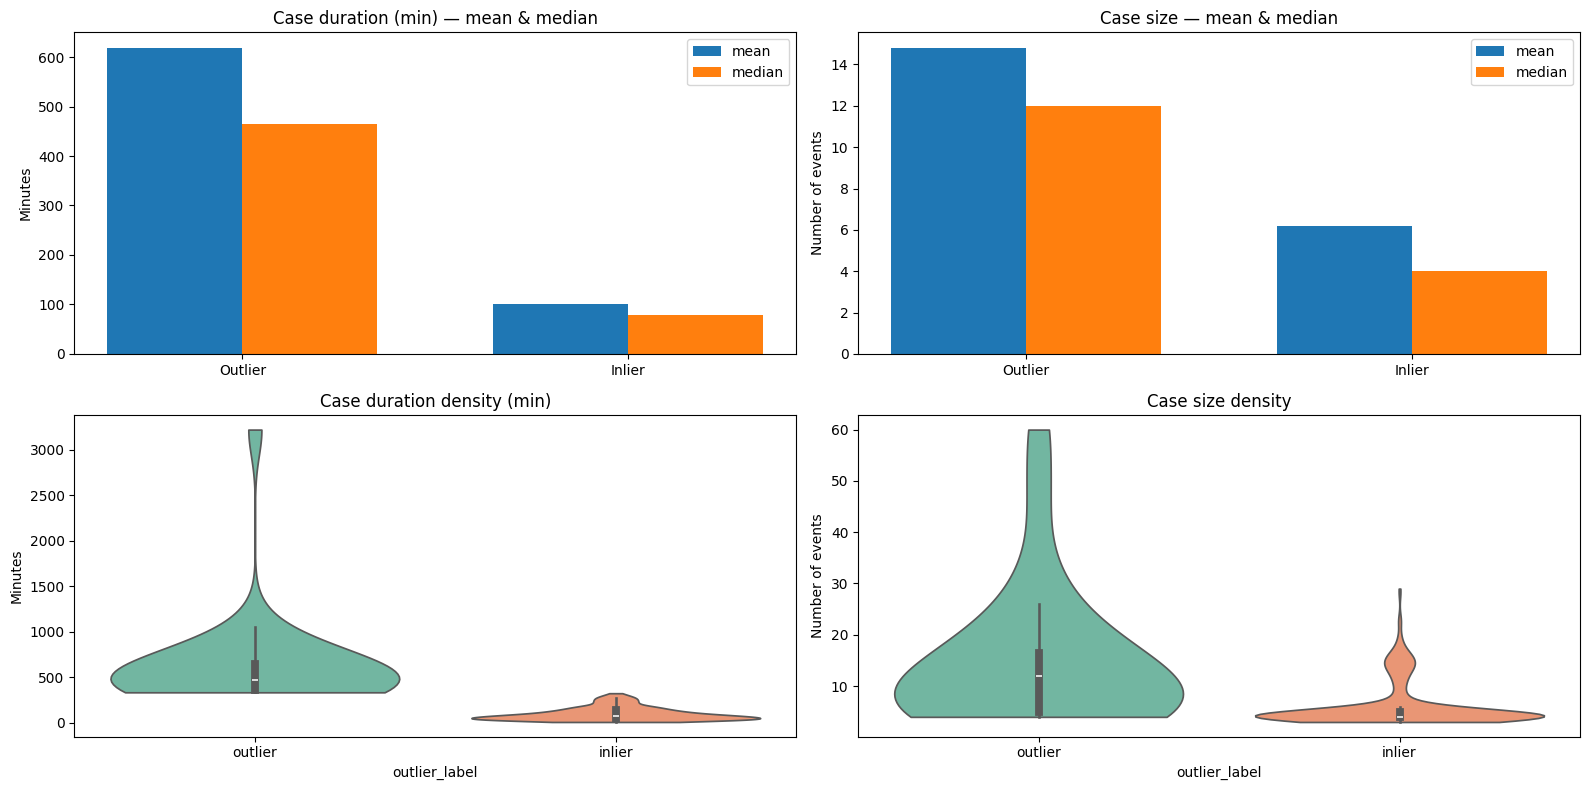

In [40]:
# Plot mean and median for duration and case size per segment
dur_mean = [kpi_outlier["duration_min"].mean(), kpi_inlier["duration_min"].mean()]
dur_med = [kpi_outlier["duration_min"].median(), kpi_inlier["duration_min"].median()]

size_mean = [kpi_outlier["case_size"].mean(), kpi_inlier["case_size"].mean()]
size_med = [kpi_outlier["case_size"].median(), kpi_inlier["case_size"].median()]

kpi_no_return_plot = kpi_outlier.copy()
kpi_no_return_plot['outlier_label'] = 'outlier'

kpi_with_return_plot = kpi_inlier.copy()
kpi_with_return_plot['outlier_label'] = 'inlier'

combined_kpis = pd.concat([kpi_no_return_plot, kpi_with_return_plot])

labels = ["Outlier", "Inlier"]
x = [0, 1]
width = 0.35

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 8))

# Duration plot
ax1.bar([xi - width / 2 for xi in x], dur_mean, width, label="mean")
ax1.bar([xi + width / 2 for xi in x], dur_med, width, label="median")
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_title("Case duration (min) — mean & median")
ax1.set_ylabel("Minutes")
ax1.legend()

# Case size plot
ax2.bar([xi - width / 2 for xi in x], size_mean, width, label="mean")
ax2.bar([xi + width / 2 for xi in x], size_med, width, label="median")
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.set_title("Case size — mean & median")
ax2.set_ylabel("Number of events")
ax2.legend()

# Duration plot
sns.violinplot(data=combined_kpis, x='outlier_label', y='duration_min', ax=ax3, palette='Set2', cut=0)
ax3.set_title("Case duration density (min)")
ax3.set_ylabel("Minutes")

# Case size plot
sns.violinplot(data=combined_kpis, x='outlier_label', y='case_size', ax=ax4, palette='Set2', cut=0)
ax4.set_title("Case size density")
ax4.set_ylabel("Number of events")

plt.tight_layout()
plt.show()

In [41]:
# Test KPIs between segments by Retorno (discharge)
print("\n=== Statistical Analysis ===")
kpis_to_test = ["duration_min", "case_size"]
compute_case_kpis_tests(kpi_discharged, kpi_readmitted, kpis_to_test)


=== Statistical Analysis ===
--- KPI: duration_min (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0001 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0021
✅ There is a statistically significant difference between the two segments for 'duration_min'.

--- KPI: case_size (Sample sizes: a=411, b=25) ---
Normality of segment a (Shapiro p-value): 0.0000 -> Non-normal
Normality of segment b (Shapiro p-value): 0.0004 -> Non-normal
At least one sample is not normal. Performing Mann-Whitney U test.
Risultato Mann-Whitney U p-value: 0.0000
✅ There is a statistically significant difference between the two segments for 'case_size'.



Conclusion: There are a significant difference for case duration and case size between outlier and inlier segment.

### Readmissions and disease correlation

In [42]:
# Aggregate at case level to get one row per case with discharge_status and disease
corr_df = df.groupby("case:concept:name").agg(
    disease=("disease", "first"),
    discharge_status=("discharge_status", "first")
).reset_index()

corr_df["readmitted"] = (corr_df["discharge_status"] != "Sem retorno").astype(int)

corr_df.head()

,case:concept:name,disease,discharge_status,readmitted
0,5446538,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
1,5446540,R07.3 Outr dor toracica,Sem retorno,0
2,5446761,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
3,5446799,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0
4,5446806,J11.1 Influenza c/out manif resp dev virus n i...,Sem retorno,0


<Figure size 1600x800 with 0 Axes>

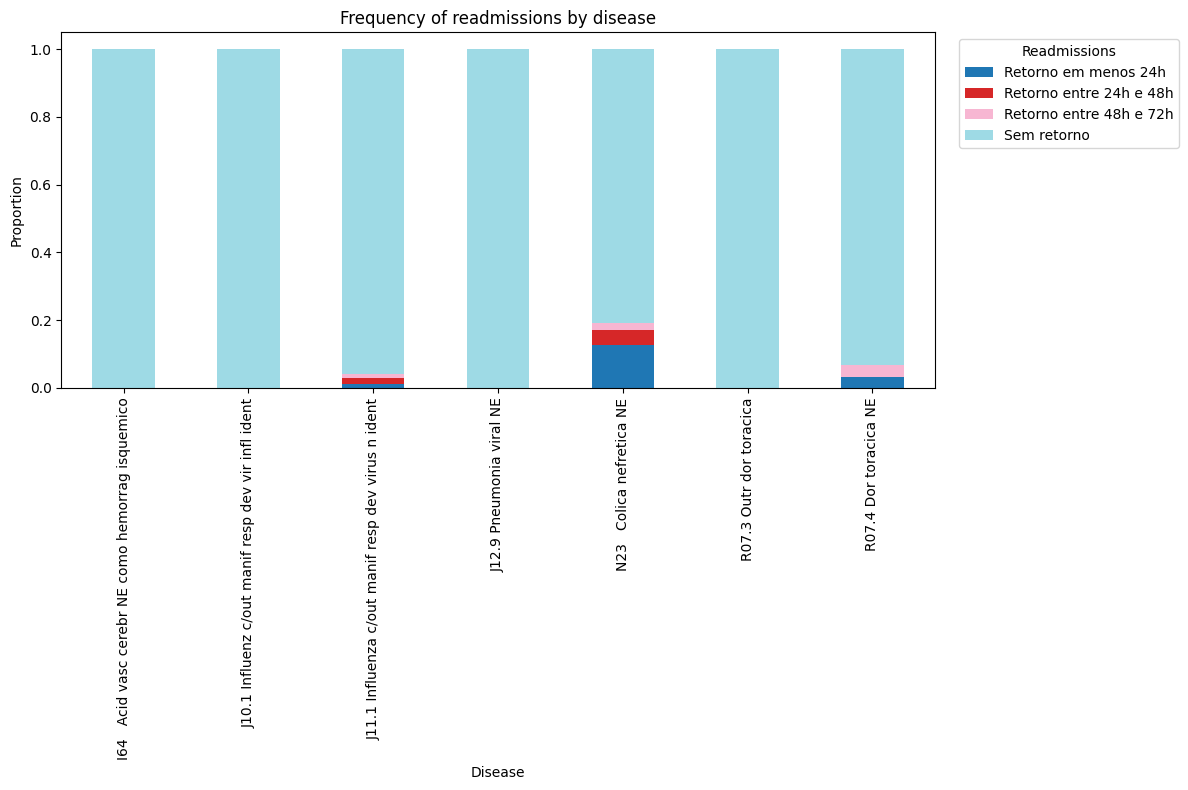

C:\Users\milan\AppData\Local\Temp\ipykernel_22244\1257356069.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")


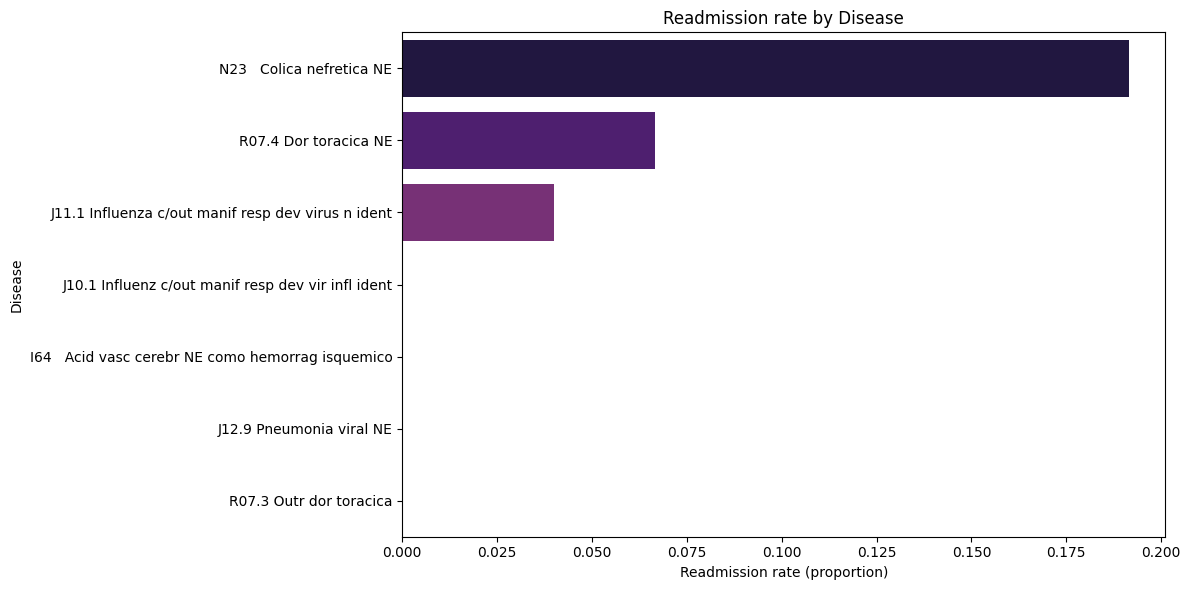

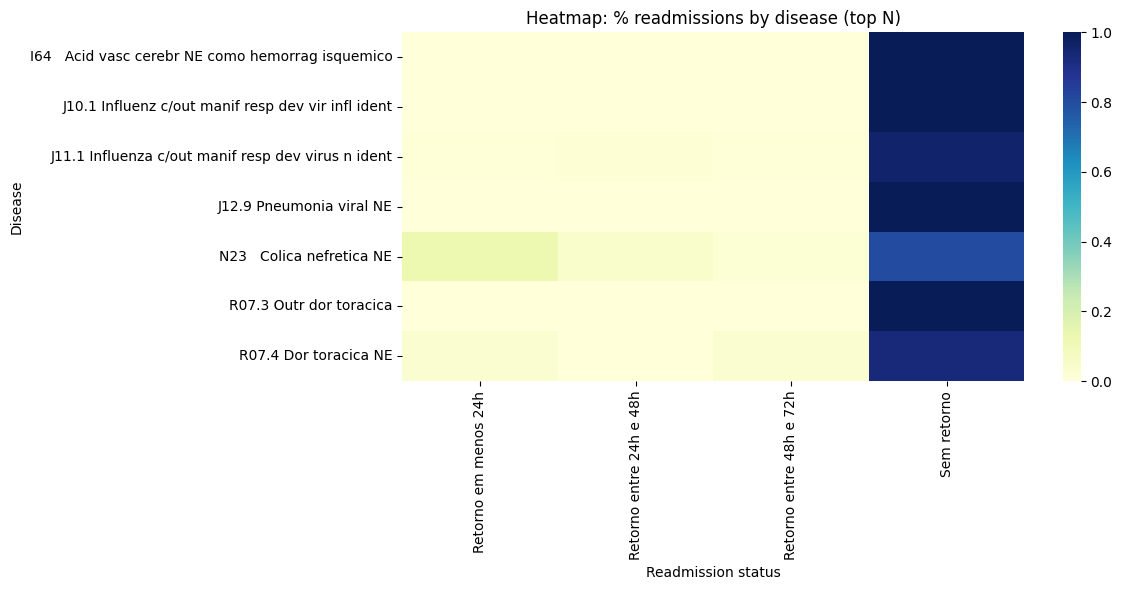

In [ ]:
# Crosstab for diseasea and discharge_status 
ct = pd.crosstab(corr_df["disease"], corr_df["discharge_status"])
ct_pct = ct.div(ct.sum(axis=1), axis=0)

# Plot stacked bar: frequency of Retorno by disease
plt.figure(figsize=(16, 8))
ct_pct.plot(kind="bar", stacked=True, colormap="tab20", figsize=(12, 8))
plt.title("Frequency of readmissions by disease")
plt.ylabel("Proportion")
plt.xlabel("Disease")
plt.legend(title="Readmissions", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Plot readmission rate per disease
readmit_rate = corr_df.groupby("disease")["readmitted"].mean().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=readmit_rate.values, y=readmit_rate.index, palette="magma")
plt.xlabel("Readmission rate (proportion)")
plt.ylabel("Disease")
plt.title("Readmission rate by Disease")
plt.tight_layout()
plt.show()

# Heatmap of percentages
plt.figure(figsize=(12, 6))
sns.heatmap(ct_pct, cmap="YlGnBu", annot=False)
plt.title("Heatmap: % readmissions by disease")
plt.ylabel("Disease")
plt.xlabel("Readmission status")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [45]:
# 7) Test statistico di indipendenza (chi-squared) sulla tabella completa top-N
chi2, p_chi2, dof, expected = chi2_contingency(ct)
print(f"Chi2 test: chi2={chi2:.2f}, p-value={p_chi2:.4f}, dof={dof}")

# 8) Analisi per malattia: odds ratio e fisher_exact (p-value)
rows = []
for disease in corr_df["disease"].unique():
    a = int(((corr_df["disease"] == disease) & (corr_df["readmitted"] == 1)).sum())  # disease & readmitted
    b = int(((corr_df["disease"] == disease) & (corr_df["readmitted"] == 0)).sum())  # disease & no readmitted
    c = int(((corr_df["disease"] != disease) & (corr_df["readmitted"] == 1)).sum())  # others & readmitted
    d = int(((corr_df["disease"] != disease) & (corr_df["readmitted"] == 0)).sum())  # others & no readmitted
    # evita divisione per zero; fisher_exact gestisce matrici con zeri
    try:
        or_stat, p_fisher = fisher_exact([[a, b], [c, d]])
    except Exception:
        or_stat, p_fisher = np.nan, np.nan
    rows.append({"disease": disease, "a_readmit": a, "b_no": b, "OR": or_stat, "p_fisher": p_fisher,
                 "readmit_rate": a / (a + b) if (a + b) > 0 else np.nan, "count": a + b})

ris = pd.DataFrame(rows).sort_values("p_fisher").reset_index(drop=True)
display(ris)

# 9) Interpretazione rapida (stampa sintetica)
sig = ris[ris["p_fisher"] < 0.05]
print(f"\nMalattie con associazione significativa (fisher p<0.05): {len(sig)}")
if len(sig) > 0:
    print(sig[["disease","count","readmit_rate","OR","p_fisher"]].head(10).to_string(index=False))
else:
    print("Nessuna associazione significativa trovata tra le top diseases e il tipo di 'Retorno' (con Fisher).")

Chi2 test: chi2=27.10, p-value=0.0771, dof=18


,disease,a_readmit,b_no,OR,p_fisher,readmit_rate,count
0,N23 Colica nefretica NE,9,38,5.521382,0.000501,0.191489,47
1,J11.1 Influenza c/out manif resp dev virus n i...,14,335,0.288738,0.004221,0.040115,349
2,R07.4 Dor toracica NE,2,28,1.189441,0.686665,0.066667,30
3,R07.3 Outr dor toracica,0,5,0.000000,1.000000,0.000000,5
4,J12.9 Pneumonia viral NE,0,3,0.000000,1.000000,0.000000,3
5,I64 Acid vasc cerebr NE como hemorrag isquemico,0,1,0.000000,1.000000,0.000000,1
6,J10.1 Influenz c/out manif resp dev vir infl i...,0,1,0.000000,1.000000,0.000000,1



Malattie con associazione significativa (fisher p<0.05): 2
                                           disease  count  readmit_rate       OR  p_fisher
                         N23   Colica nefretica NE     47      0.191489 5.521382  0.000501
J11.1 Influenza c/out manif resp dev virus n ident    349      0.040115 0.288738  0.004221
